<a href="https://colab.research.google.com/github/Sameer0Rai/Deep-Learning/blob/main/Lab-Assignments/Lab-7/Lab_7_Everything.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(22)

In [3]:
EPSILON= 1e-8

In [4]:
N=3000
x1= np.random.uniform(-2,2,N)
x2= np.random.uniform(-2,2,N)
y = ((x1**2 + x2**2) > 1.5).astype(float).reshape(-1,1)

In [5]:
X= np.column_stack([x1, x2])

In [6]:
def split_data(X,y, train_ratio=0.7, val_ratio=0.15):
    N = len(X)
    idx= np.random.permutation(N)
    train_end = int(N*train_ratio)
    val_end = int(N* (train_ratio + val_ratio))

    train_idx = idx[:train_end]
    val_idx = idx[train_end: val_end]
    test_idx = idx[val_end:]

    return (X[train_idx], y[train_idx], X[val_idx], y[val_idx],X[test_idx], y[test_idx])

X_train, y_train, X_val, y_val, X_test, y_test= split_data(X,y)

print(f"Train size: {X_train.shape[0]}")
print(f"Val size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 2100
Val size: 450
Test size: 450


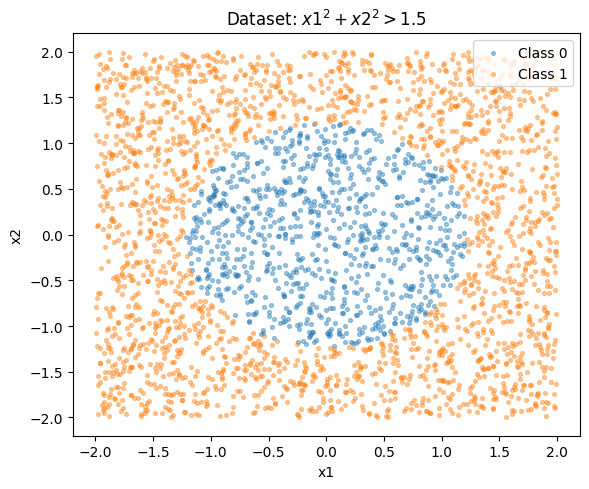

In [7]:
plt.figure(figsize=(6,5))
plt.scatter(x1[y.flatten()==0], x2[y.flatten()==0], s=8, alpha=0.4, label='Class 0')
plt.scatter(x1[y.flatten()==1], x2[y.flatten()==1], s=8, alpha=0.4, label= 'Class 1')
plt.title("Dataset: $x1^2 + x2^2 > 1.5$")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.tight_layout(); plt.show()

In [8]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z,-500,500)))

def sigmoid_derivative(a):
    return a*(1.0-a)

def relu(z):
    return np.maximum(0,z)

def relu_derivative(a):
    return (a>0).astype(float)

In [9]:
def bce_loss(y_pred, y_true):
    y_pred = np.clip(y_pred, EPSILON, 1 - EPSILON)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


In [10]:

def accuracy(y_pred, y_true):
    return np.mean((y_pred >= 0.5).astype(float) == y_true)

# frobenius norm of gradient matrix
def frobenius_norm(grad_W):
    return np.sqrt(np.sum(grad_W ** 2))

def plot_history(history, title, save=True):
    import os
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title(title + ' - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[1].plot(history['train_acc'], label='Train Acc')
    axes[1].plot(history['val_acc'], label='Val Acc')
    axes[1].set_title(title + ' - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    if save:
        os.makedirs('plots', exist_ok=True)
        plt.savefig('plots/' + title + '.png', dpi=100)
    plt.show()


## PART 1 — Task 1A: Build Three Dense Architectures

**Formula per layer:**  `params = (n_in × n_out) + n_out`

**2-layer** `[2→16→1]`:  
- Layer 1: (2×16)+16 = 48  
- Layer 2: (16×1)+1  = 17  
- **Total = 65**

**5-layer** `[2→16→16→16→16→1]`:  
- Layer 1: 48 | Layer 2-4: (16×16)+16 = 272 each | Layer 5: 17  
- **Total = 48 + 3×272 + 17 = 881**

**10-layer** `[2→16×9→1]`:  
- Layer 1: 48 | Layers 2-9: 272 each (×8) | Layer 10: 17  
- **Total = 48 + 8×272 + 17 = 2241**

In [11]:

class DenseNetwork:
    def __init__(self, layer_sizes, activation='sigmoid'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.weights = []
        self.biases = []
        self.grad_weights = []
        self.grad_biases = []
        self._init_params()

    def _init_params(self):
        for i in range(len(self.layer_sizes) - 1):
            n_in = self.layer_sizes[i]
            n_out = self.layer_sizes[i + 1]
            # He init for relu, Xavier for sigmoid
            if self.activation == 'relu':
                scale = np.sqrt(2.0 / n_in)
            else:
                scale = np.sqrt(1.0 / n_in)
            self.weights.append(np.random.randn(n_in, n_out) * scale)
            self.biases.append(np.zeros((1, n_out)))

    def count_parameters(self):
        total = 0
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            p = W.size + b.size
            total += p
            print(f'Layer {i+1}: W{W.shape} + b{b.shape} = {p}')
        print(f'Total params: {total}')
        return total

    def forward(self, X):
        self.activations = [X]
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = self.activations[-1] @ W + b
            is_last = (i == len(self.weights) - 1)
            if is_last:
                a = sigmoid(z)
            elif self.activation == 'sigmoid':
                a = sigmoid(z)
            else:
                a = relu(z)
            self.activations.append(a)
        return self.activations[-1]

    def backward(self, y_true):
        m = y_true.shape[0]
        grad_weights = [None] * len(self.weights)
        grad_biases = [None] * len(self.biases)

        # for BCE + sigmoid output, delta = (y_hat - y) / m
        delta = (self.activations[-1] - y_true) / m

        for i in reversed(range(len(self.weights))):
            grad_weights[i] = self.activations[i].T @ delta
            grad_biases[i] = np.sum(delta, axis=0, keepdims=True)
            if i > 0:
                delta = delta @ self.weights[i].T
                if self.activation == 'sigmoid':
                    delta = delta * sigmoid_derivative(self.activations[i])
                else:
                    delta = delta * relu_derivative(self.activations[i])

        self.grad_weights = grad_weights
        self.grad_biases = grad_biases
        return grad_weights, grad_biases

    def get_gradient_norms(self):
        return [frobenius_norm(gW) for gW in self.grad_weights]


In [12]:

class SGD:
    def __init__(self, lr=0.05):
        self.lr = lr

    def update(self, net, grad_weights, grad_biases):
        for i in range(len(net.weights)):
            net.weights[i] -= self.lr * grad_weights[i]
            net.biases[i] -= self.lr * grad_biases[i]


class MomentumSGD:
    def __init__(self, lr=0.05, beta=0.9):
        self.lr = lr
        self.beta = beta
        self.vW = None
        self.vb = None

    def update(self, net, grad_weights, grad_biases):
        if self.vW is None:
            self.vW = [np.zeros_like(w) for w in net.weights]
            self.vb = [np.zeros_like(b) for b in net.biases]
        for i in range(len(net.weights)):
            # v = beta*v + lr*grad
            self.vW[i] = self.beta * self.vW[i] + self.lr * grad_weights[i]
            self.vb[i] = self.beta * self.vb[i] + self.lr * grad_biases[i]
            net.weights[i] -= self.vW[i]
            net.biases[i] -= self.vb[i]


class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.mW = self.vW = self.mb = self.vb = None
        self.t = 0

    def update(self, net, grad_weights, grad_biases):
        if self.mW is None:
            self.mW = [np.zeros_like(w) for w in net.weights]
            self.vW = [np.zeros_like(w) for w in net.weights]
            self.mb = [np.zeros_like(b) for b in net.biases]
            self.vb = [np.zeros_like(b) for b in net.biases]
        self.t += 1
        for i in range(len(net.weights)):
            self.mW[i] = self.beta1 * self.mW[i] + (1 - self.beta1) * grad_weights[i]
            self.vW[i] = self.beta2 * self.vW[i] + (1 - self.beta2) * grad_weights[i]**2
            m_hat = self.mW[i] / (1 - self.beta1**self.t)
            v_hat = self.vW[i] / (1 - self.beta2**self.t)
            net.weights[i] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

            self.mb[i] = self.beta1 * self.mb[i] + (1 - self.beta1) * grad_biases[i]
            self.vb[i] = self.beta2 * self.vb[i] + (1 - self.beta2) * grad_biases[i]**2
            mb_hat = self.mb[i] / (1 - self.beta1**self.t)
            vb_hat = self.vb[i] / (1 - self.beta2**self.t)
            net.biases[i] -= self.lr * mb_hat / (np.sqrt(vb_hat) + self.eps)


## Training Loop

In [13]:

def train_model(net, optimizer, X_tr, y_tr, X_vl, y_vl,
                epochs=200, batch_size=64, verbose=True):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'grad_norms': []}
    N = X_tr.shape[0]

    for epoch in range(epochs):
        # shuffle each epoch
        idx = np.random.permutation(N)
        Xs, ys = X_tr[idx], y_tr[idx]

        for start in range(0, N, batch_size):
            Xb = Xs[start:start + batch_size]
            yb = ys[start:start + batch_size]
            net.forward(Xb)
            gW, gb = net.backward(yb)
            optimizer.update(net, gW, gb)

        # evaluate on full train and val sets
        yp_tr = net.forward(X_tr)
        yp_vl = net.forward(X_vl)
        tl = bce_loss(yp_tr, y_tr)
        vl = bce_loss(yp_vl, y_vl)
        ta = accuracy(yp_tr, y_tr)
        va = accuracy(yp_vl, y_vl)

        # gradient norms using a mini batch
        net.forward(X_tr[:batch_size])
        net.backward(y_tr[:batch_size])
        norms = net.get_gradient_norms()

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        history['grad_norms'].append(norms)

        if verbose and (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch+1} | train_loss={tl:.4f} val_loss={vl:.4f} | train_acc={ta:.4f} val_acc={va:.4f}')

    return history


def evaluate_model(net, X_test, y_test, label='Test'):
    yp = net.forward(X_test)
    l = bce_loss(yp, y_test)
    a = accuracy(yp, y_test)
    print(f'{label} -> loss={l:.4f}  acc={a:.4f}')
    return l, a



Training: 2-layer_sigmoid_SGD
Layer 1: W(2, 16) + b(1, 16) = 48
Layer 2: W(16, 1) + b(1, 1) = 17
Total params: 65
Epoch 50 | train_loss=0.5930 val_loss=0.5892 | train_acc=0.7095 val_acc=0.7156
Epoch 100 | train_loss=0.5387 val_loss=0.5437 | train_acc=0.7095 val_acc=0.7156
Epoch 150 | train_loss=0.4086 val_loss=0.4278 | train_acc=0.8376 val_acc=0.8289
Epoch 200 | train_loss=0.2874 val_loss=0.3027 | train_acc=0.9195 val_acc=0.8978
Test -> loss=0.2910  acc=0.9022


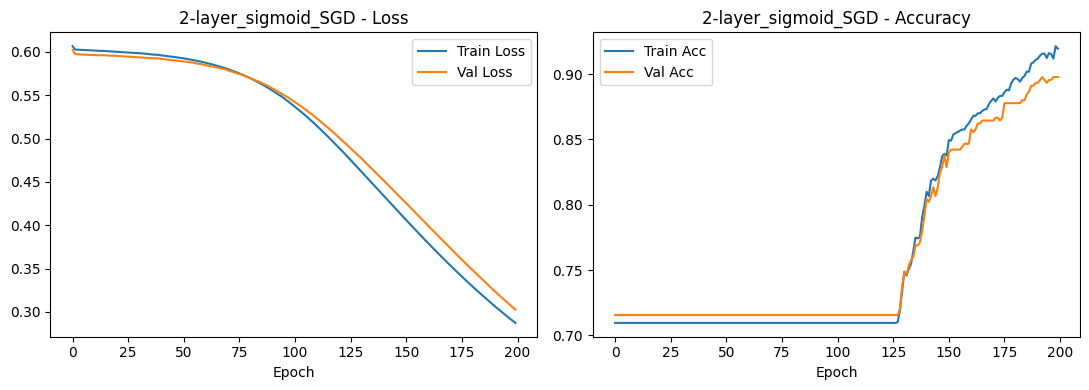


Training: 2-layer_sigmoid_Momentum
Layer 1: W(2, 16) + b(1, 16) = 48
Layer 2: W(16, 1) + b(1, 1) = 17
Total params: 65
Epoch 50 | train_loss=0.1107 val_loss=0.1114 | train_acc=0.9729 val_acc=0.9756
Epoch 100 | train_loss=0.0668 val_loss=0.0689 | train_acc=0.9962 val_acc=0.9933
Epoch 150 | train_loss=0.0534 val_loss=0.0542 | train_acc=0.9943 val_acc=0.9933
Epoch 200 | train_loss=0.0459 val_loss=0.0474 | train_acc=0.9971 val_acc=0.9933
Test -> loss=0.0461  acc=0.9889


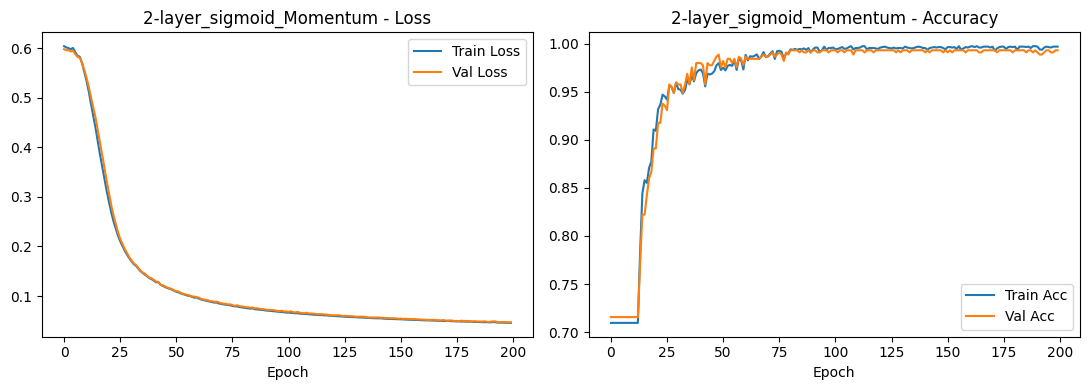


Training: 2-layer_relu_SGD
Layer 1: W(2, 16) + b(1, 16) = 48
Layer 2: W(16, 1) + b(1, 1) = 17
Total params: 65
Epoch 50 | train_loss=0.1229 val_loss=0.1273 | train_acc=0.9686 val_acc=0.9733
Epoch 100 | train_loss=0.0839 val_loss=0.0861 | train_acc=0.9857 val_acc=0.9822
Epoch 150 | train_loss=0.0666 val_loss=0.0678 | train_acc=0.9900 val_acc=0.9889
Epoch 200 | train_loss=0.0567 val_loss=0.0582 | train_acc=0.9933 val_acc=0.9911
Test -> loss=0.0571  acc=0.9867


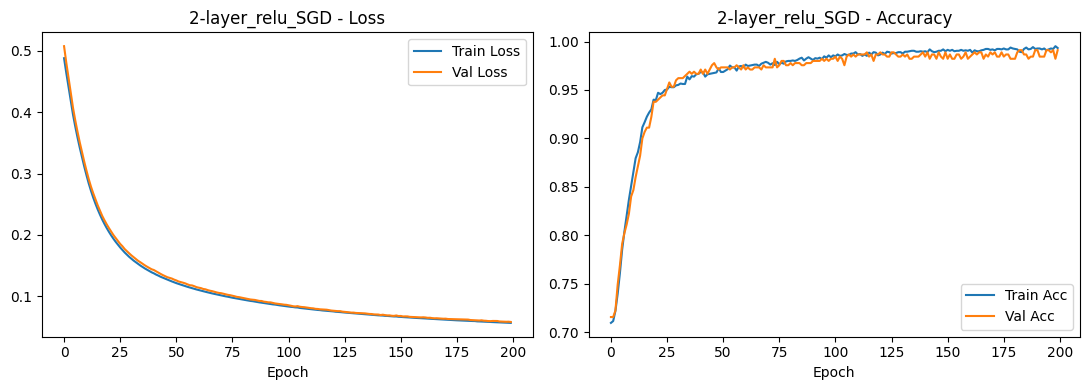


Training: 2-layer_relu_Momentum
Layer 1: W(2, 16) + b(1, 16) = 48
Layer 2: W(16, 1) + b(1, 1) = 17
Total params: 65
Epoch 50 | train_loss=0.0371 val_loss=0.0371 | train_acc=0.9905 val_acc=0.9867
Epoch 100 | train_loss=0.0233 val_loss=0.0267 | train_acc=0.9971 val_acc=0.9911
Epoch 150 | train_loss=0.0195 val_loss=0.0203 | train_acc=0.9952 val_acc=0.9933
Epoch 200 | train_loss=0.0159 val_loss=0.0207 | train_acc=0.9976 val_acc=0.9933
Test -> loss=0.0244  acc=0.9911


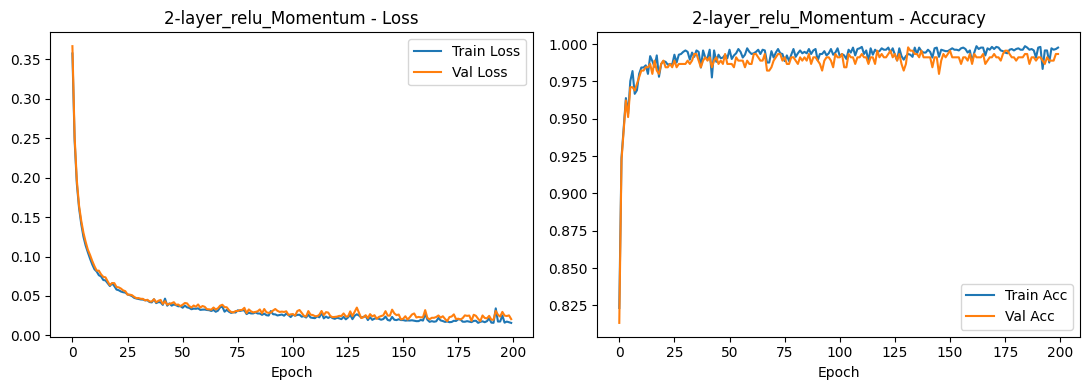


Training: 5-layer_sigmoid_SGD
Layer 1: W(2, 16) + b(1, 16) = 48
Layer 2: W(16, 16) + b(1, 16) = 272
Layer 3: W(16, 16) + b(1, 16) = 272
Layer 4: W(16, 16) + b(1, 16) = 272
Layer 5: W(16, 1) + b(1, 1) = 17
Total params: 881
Epoch 50 | train_loss=0.6026 val_loss=0.5972 | train_acc=0.7095 val_acc=0.7156
Epoch 100 | train_loss=0.6026 val_loss=0.5972 | train_acc=0.7095 val_acc=0.7156
Epoch 150 | train_loss=0.6027 val_loss=0.5974 | train_acc=0.7095 val_acc=0.7156
Epoch 200 | train_loss=0.6026 val_loss=0.5972 | train_acc=0.7095 val_acc=0.7156
Test -> loss=0.6208  acc=0.6889


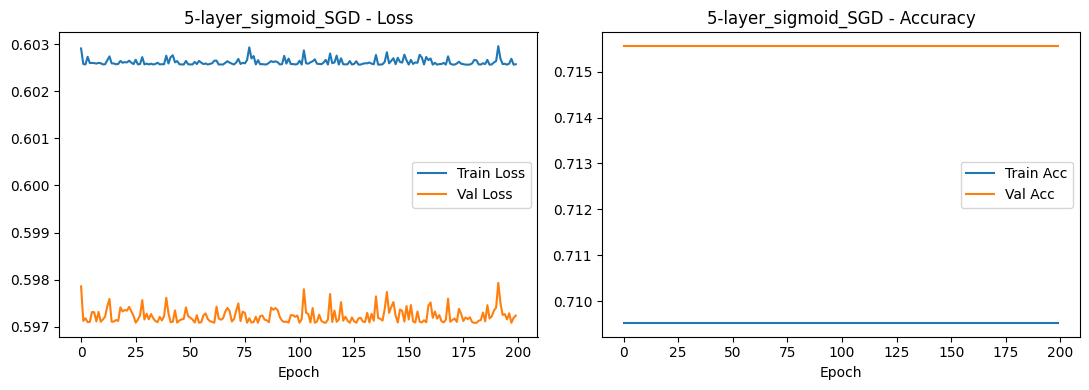


Training: 5-layer_sigmoid_Momentum
Layer 1: W(2, 16) + b(1, 16) = 48
Layer 2: W(16, 16) + b(1, 16) = 272
Layer 3: W(16, 16) + b(1, 16) = 272
Layer 4: W(16, 16) + b(1, 16) = 272
Layer 5: W(16, 1) + b(1, 1) = 17
Total params: 881
Epoch 50 | train_loss=0.6038 val_loss=0.5977 | train_acc=0.7095 val_acc=0.7156
Epoch 100 | train_loss=0.6026 val_loss=0.5971 | train_acc=0.7095 val_acc=0.7156
Epoch 150 | train_loss=0.6028 val_loss=0.5977 | train_acc=0.7095 val_acc=0.7156
Epoch 200 | train_loss=0.6025 val_loss=0.5971 | train_acc=0.7095 val_acc=0.7156
Test -> loss=0.6211  acc=0.6889


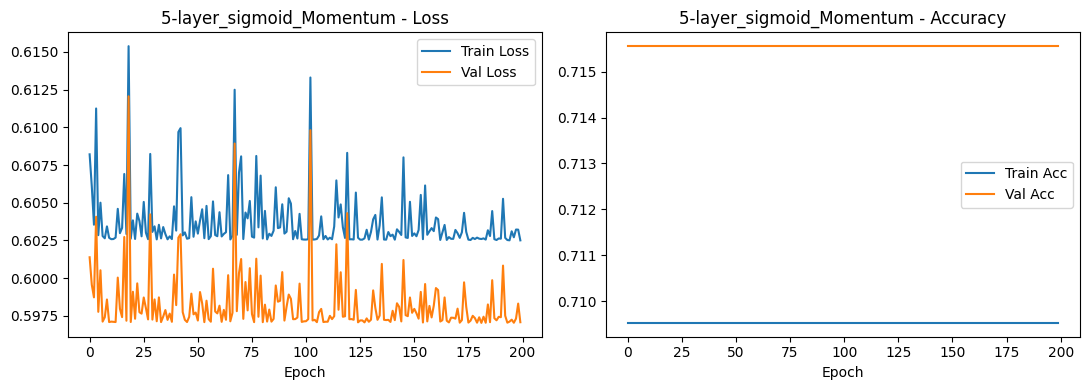


Training: 5-layer_relu_SGD
Layer 1: W(2, 16) + b(1, 16) = 48
Layer 2: W(16, 16) + b(1, 16) = 272
Layer 3: W(16, 16) + b(1, 16) = 272
Layer 4: W(16, 16) + b(1, 16) = 272
Layer 5: W(16, 1) + b(1, 1) = 17
Total params: 881
Epoch 50 | train_loss=0.0258 val_loss=0.0290 | train_acc=0.9943 val_acc=0.9911
Epoch 100 | train_loss=0.0159 val_loss=0.0194 | train_acc=0.9938 val_acc=0.9933
Epoch 150 | train_loss=0.0506 val_loss=0.0452 | train_acc=0.9819 val_acc=0.9867
Epoch 200 | train_loss=0.0090 val_loss=0.0165 | train_acc=0.9981 val_acc=0.9933
Test -> loss=0.0208  acc=0.9889


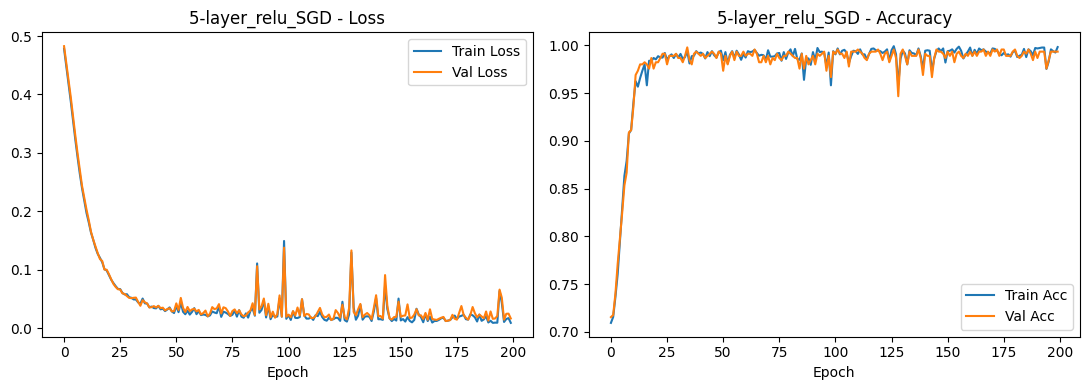


Training: 5-layer_relu_Momentum
Layer 1: W(2, 16) + b(1, 16) = 48
Layer 2: W(16, 16) + b(1, 16) = 272
Layer 3: W(16, 16) + b(1, 16) = 272
Layer 4: W(16, 16) + b(1, 16) = 272
Layer 5: W(16, 1) + b(1, 1) = 17
Total params: 881
Epoch 50 | train_loss=0.0359 val_loss=0.0370 | train_acc=0.9886 val_acc=0.9822
Epoch 100 | train_loss=0.0297 val_loss=0.0262 | train_acc=0.9881 val_acc=0.9867
Epoch 150 | train_loss=0.0200 val_loss=0.0351 | train_acc=0.9919 val_acc=0.9822
Epoch 200 | train_loss=0.0098 val_loss=0.0153 | train_acc=0.9976 val_acc=0.9911
Test -> loss=0.0152  acc=0.9933


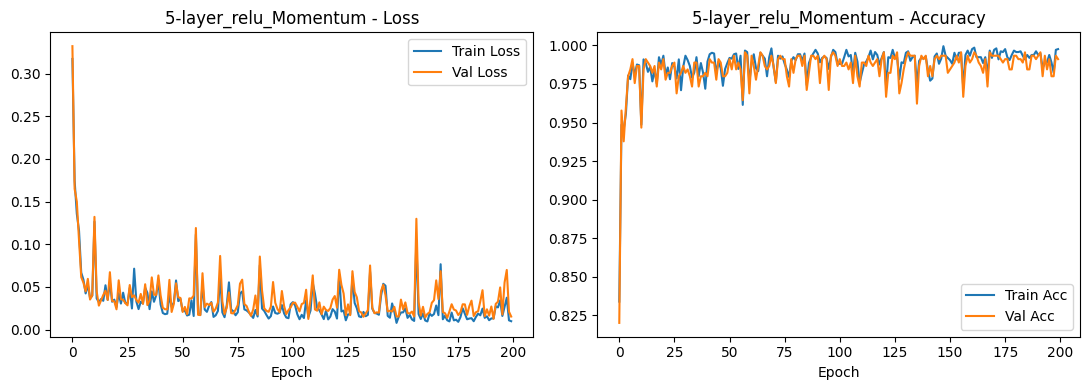


Training: 10-layer_sigmoid_SGD
Layer 1: W(2, 16) + b(1, 16) = 48
Layer 2: W(16, 16) + b(1, 16) = 272
Layer 3: W(16, 16) + b(1, 16) = 272
Layer 4: W(16, 16) + b(1, 16) = 272
Layer 5: W(16, 16) + b(1, 16) = 272
Layer 6: W(16, 16) + b(1, 16) = 272
Layer 7: W(16, 16) + b(1, 16) = 272
Layer 8: W(16, 16) + b(1, 16) = 272
Layer 9: W(16, 16) + b(1, 16) = 272
Layer 10: W(16, 1) + b(1, 1) = 17
Total params: 2241
Epoch 50 | train_loss=0.6026 val_loss=0.5972 | train_acc=0.7095 val_acc=0.7156
Epoch 100 | train_loss=0.6030 val_loss=0.5972 | train_acc=0.7095 val_acc=0.7156
Epoch 150 | train_loss=0.6028 val_loss=0.5976 | train_acc=0.7095 val_acc=0.7156
Epoch 200 | train_loss=0.6026 val_loss=0.5971 | train_acc=0.7095 val_acc=0.7156
Test -> loss=0.6213  acc=0.6889


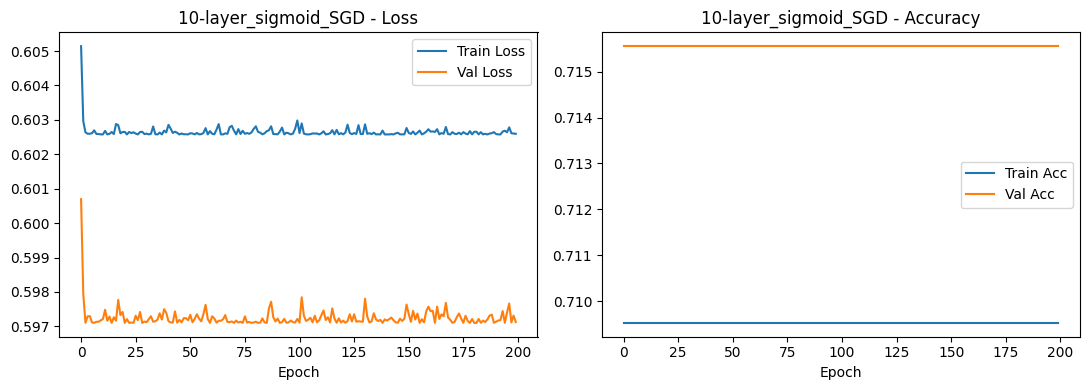


Training: 10-layer_sigmoid_Momentum
Layer 1: W(2, 16) + b(1, 16) = 48
Layer 2: W(16, 16) + b(1, 16) = 272
Layer 3: W(16, 16) + b(1, 16) = 272
Layer 4: W(16, 16) + b(1, 16) = 272
Layer 5: W(16, 16) + b(1, 16) = 272
Layer 6: W(16, 16) + b(1, 16) = 272
Layer 7: W(16, 16) + b(1, 16) = 272
Layer 8: W(16, 16) + b(1, 16) = 272
Layer 9: W(16, 16) + b(1, 16) = 272
Layer 10: W(16, 1) + b(1, 1) = 17
Total params: 2241
Epoch 50 | train_loss=0.6037 val_loss=0.5989 | train_acc=0.7095 val_acc=0.7156
Epoch 100 | train_loss=0.6047 val_loss=0.5984 | train_acc=0.7095 val_acc=0.7156
Epoch 150 | train_loss=0.6064 val_loss=0.6022 | train_acc=0.7095 val_acc=0.7156
Epoch 200 | train_loss=0.6026 val_loss=0.5973 | train_acc=0.7095 val_acc=0.7156
Test -> loss=0.6208  acc=0.6889


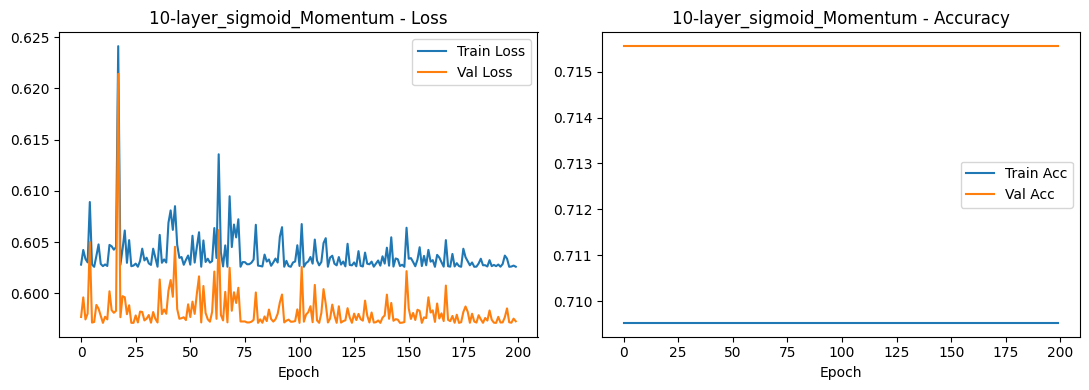


Training: 10-layer_relu_SGD
Layer 1: W(2, 16) + b(1, 16) = 48
Layer 2: W(16, 16) + b(1, 16) = 272
Layer 3: W(16, 16) + b(1, 16) = 272
Layer 4: W(16, 16) + b(1, 16) = 272
Layer 5: W(16, 16) + b(1, 16) = 272
Layer 6: W(16, 16) + b(1, 16) = 272
Layer 7: W(16, 16) + b(1, 16) = 272
Layer 8: W(16, 16) + b(1, 16) = 272
Layer 9: W(16, 16) + b(1, 16) = 272
Layer 10: W(16, 1) + b(1, 1) = 17
Total params: 2241
Epoch 50 | train_loss=0.0251 val_loss=0.0294 | train_acc=0.9924 val_acc=0.9867
Epoch 100 | train_loss=0.0372 val_loss=0.0438 | train_acc=0.9814 val_acc=0.9844
Epoch 150 | train_loss=0.0128 val_loss=0.0396 | train_acc=0.9943 val_acc=0.9822
Epoch 200 | train_loss=0.0174 val_loss=0.0324 | train_acc=0.9919 val_acc=0.9911
Test -> loss=0.0376  acc=0.9889


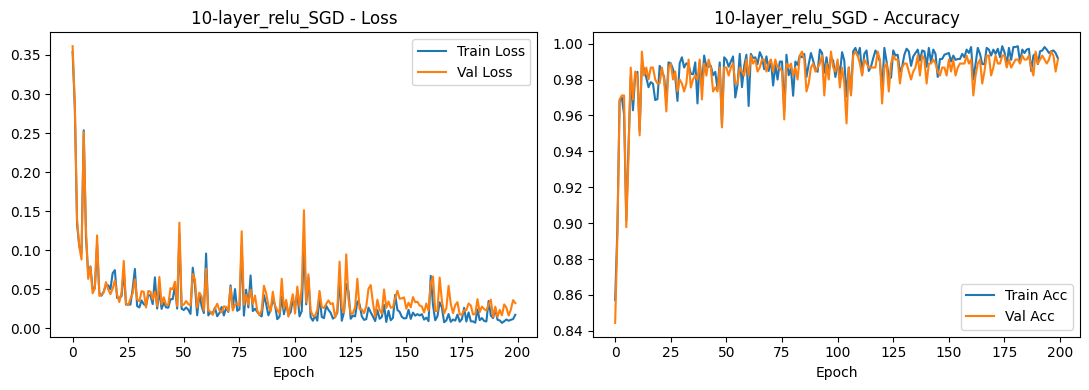


Training: 10-layer_relu_Momentum
Layer 1: W(2, 16) + b(1, 16) = 48
Layer 2: W(16, 16) + b(1, 16) = 272
Layer 3: W(16, 16) + b(1, 16) = 272
Layer 4: W(16, 16) + b(1, 16) = 272
Layer 5: W(16, 16) + b(1, 16) = 272
Layer 6: W(16, 16) + b(1, 16) = 272
Layer 7: W(16, 16) + b(1, 16) = 272
Layer 8: W(16, 16) + b(1, 16) = 272
Layer 9: W(16, 16) + b(1, 16) = 272
Layer 10: W(16, 1) + b(1, 1) = 17
Total params: 2241
Epoch 50 | train_loss=0.0158 val_loss=0.0190 | train_acc=0.9948 val_acc=0.9911
Epoch 100 | train_loss=0.0193 val_loss=0.0206 | train_acc=0.9895 val_acc=0.9911
Epoch 150 | train_loss=0.0220 val_loss=0.0210 | train_acc=0.9890 val_acc=0.9889
Epoch 200 | train_loss=0.0213 val_loss=0.0459 | train_acc=0.9910 val_acc=0.9800
Test -> loss=0.0335  acc=0.9889


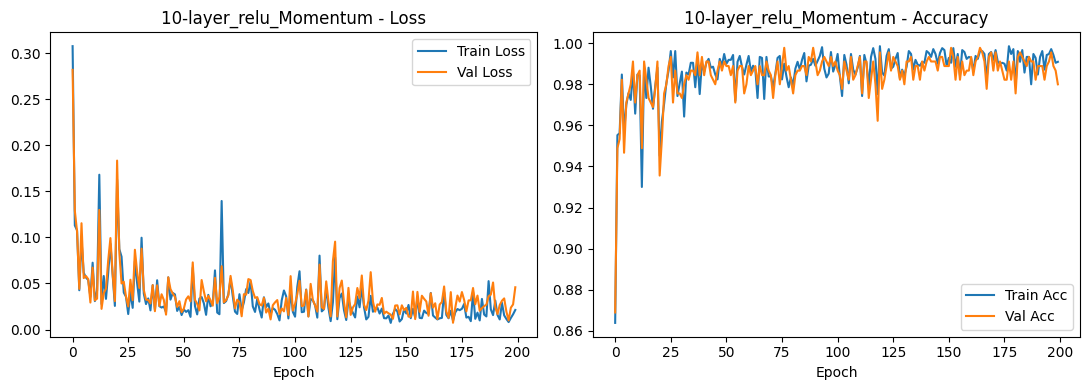

done - all 12 models trained


In [14]:

import os, warnings
os.makedirs('plots', exist_ok=True)
warnings.filterwarnings('ignore')

# 3 architectures x 2 activations x 2 optimizers = 12 models
architectures = {
    '2-layer':  [2, 16, 1],
    '5-layer':  [2, 16, 16, 16, 16, 1],
    '10-layer': [2, 16, 16, 16, 16, 16, 16, 16, 16, 16, 1],
}
activations_list = ['sigmoid', 'relu']
optimizer_configs = {
    'SGD':      lambda: SGD(lr=0.05),
    'Momentum': lambda: MomentumSGD(lr=0.05, beta=0.9),
}

EPOCHS = 200
results_p1 = {}

for arch_name, layer_sizes in architectures.items():
    for act in activations_list:
        for opt_name, opt_fn in optimizer_configs.items():
            key = f'{arch_name}_{act}_{opt_name}'
            print(f'\nTraining: {key}')

            np.random.seed(42)
            net = DenseNetwork(layer_sizes, activation=act)
            net.count_parameters()

            history = train_model(net, opt_fn(), X_train, y_train, X_val, y_val,
                                  epochs=EPOCHS, verbose=True)

            te_loss, te_acc = evaluate_model(net, X_test, y_test)
            plot_history(history, key)

            results_p1[key] = {
                'history': history,
                'net': net,
                'arch': arch_name,
                'act': act,
                'opt': opt_name,
                'params': sum(w.size + b.size for w, b in zip(net.weights, net.biases)),
                'tr_loss': history['train_loss'][-1],
                'tr_acc':  history['train_acc'][-1],
                'vl_loss': history['val_loss'][-1],
                'vl_acc':  history['val_acc'][-1],
                'te_loss': te_loss,
                'te_acc':  te_acc,
            }

print('done - all 12 models trained')


## Task 1B Add-On — Gradient Norms: 2-layer vs 10-layer Sigmoid (Vanishing Gradient Analysis)

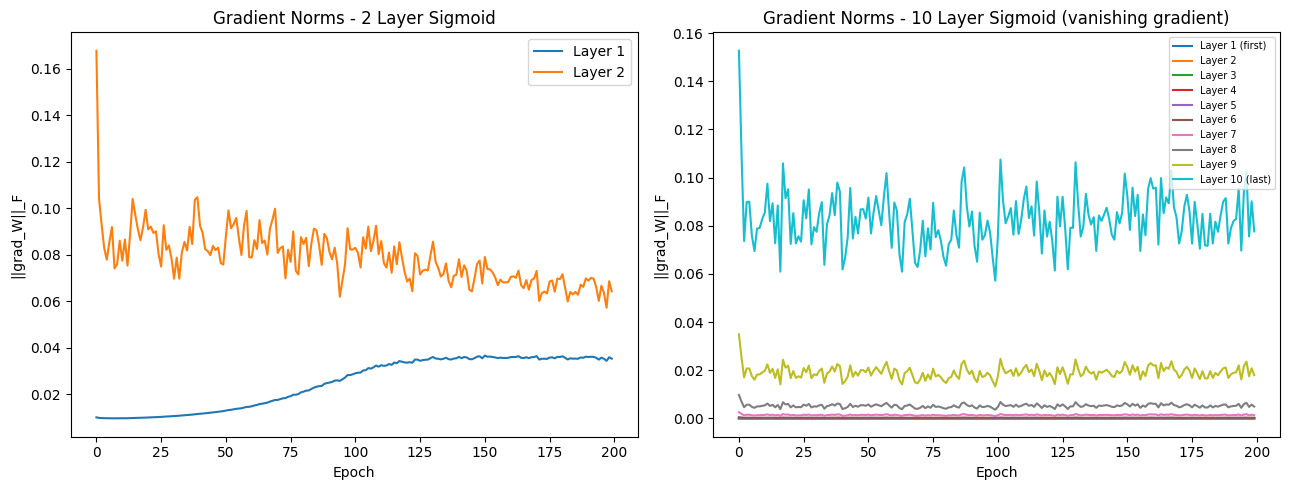

observation: first layers in the 10-layer network have near-zero gradients
this is the vanishing gradient problem with sigmoid activation


In [15]:

# compare gradient norms for 2-layer vs 10-layer sigmoid
key_2  = '2-layer_sigmoid_SGD'
key_10 = '10-layer_sigmoid_SGD'

norms_2  = np.array(results_p1[key_2]['history']['grad_norms'])
norms_10 = np.array(results_p1[key_10]['history']['grad_norms'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for li in range(norms_2.shape[1]):
    axes[0].plot(norms_2[:, li], label=f'Layer {li+1}')
axes[0].set_title('Gradient Norms - 2 Layer Sigmoid')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('||grad_W||_F')
axes[0].legend()

n_layers = norms_10.shape[1]
for li in range(n_layers):
    if li == 0:
        label = 'Layer 1 (first)'
    elif li == n_layers - 1:
        label = f'Layer {n_layers} (last)'
    else:
        label = f'Layer {li+1}'
    axes[1].plot(norms_10[:, li], label=label)
axes[1].set_title('Gradient Norms - 10 Layer Sigmoid (vanishing gradient)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('||grad_W||_F')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('plots/gradient_norms.png', dpi=100)
plt.show()

print('observation: first layers in the 10-layer network have near-zero gradients')
print('this is the vanishing gradient problem with sigmoid activation')


## Part 1 — Master Results Table & Required Analysis

In [16]:

# results table for part 1
depth_map = {'2-layer': 2, '5-layer': 5, '10-layer': 10}
print(f"{'Model':<35} Depth  Act      Opt     Params  TrainAcc  ValAcc  TestAcc")
print('-' * 85)
for key, r in results_p1.items():
    print(f"{key:<35} {depth_map[r['arch']]:<6} {r['act']:<8} {r['opt']:<10} {r['params']:<7} "
          f"{r['tr_acc']:.4f}    {r['vl_acc']:.4f}  {r['te_acc']:.4f}")

# Analysis - Part 1:
# Q1. Does depth always improve validation accuracy?
# No. 10-layer sigmoid gets hurt by vanishing gradients, validation drops.
# Q2. What happens to test performance as depth increases?
# Sigmoid: test acc drops at 10 layers. ReLU handles deeper nets better.
# Q3. Do sigmoid nets degrade faster with depth?
# Yes. sigmoid derivative is max 0.25, so 10 layers multiplies tiny gradients together.
# Q4. Does optimizer matter more in deep nets?
# Yes. Momentum helps a lot in deep nets where SGD gets stuck. Shallow nets are fine with either.
# Q5. Is validation a reliable predictor of test performance?
# Mostly yes. Both drop together in bad models, which is good - no surprise at test time.


Model                               Depth  Act      Opt     Params  TrainAcc  ValAcc  TestAcc
-------------------------------------------------------------------------------------
2-layer_sigmoid_SGD                 2      sigmoid  SGD        65      0.9195    0.8978  0.9022
2-layer_sigmoid_Momentum            2      sigmoid  Momentum   65      0.9971    0.9933  0.9889
2-layer_relu_SGD                    2      relu     SGD        65      0.9933    0.9911  0.9867
2-layer_relu_Momentum               2      relu     Momentum   65      0.9976    0.9933  0.9911
5-layer_sigmoid_SGD                 5      sigmoid  SGD        881     0.7095    0.7156  0.6889
5-layer_sigmoid_Momentum            5      sigmoid  Momentum   881     0.7095    0.7156  0.6889
5-layer_relu_SGD                    5      relu     SGD        881     0.9981    0.9933  0.9889
5-layer_relu_Momentum               5      relu     Momentum   881     0.9976    0.9911  0.9933
10-layer_sigmoid_SGD                10     sigmoid  

---
## PART 2 — From Dense to Convolution

### Dataset: Synthetic 8×8 Images (Option A)
- **Class 0**: vertical center line
- **Class 1**: horizontal center line  
- Gaussian noise σ = 0.1 added

shape: (3000, 8, 8), class balance: 0.50


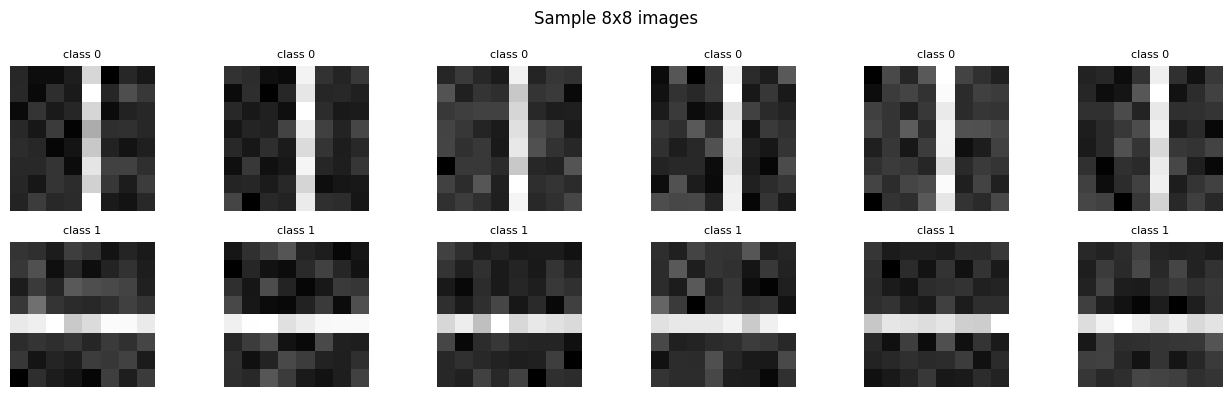

dense splits: 2100 train / 450 val / 450 test
cnn splits:   2100 train / 450 val / 450 test


In [17]:

# generate 8x8 images: class 0 = vertical line, class 1 = horizontal line
def generate_image_dataset(N=3000, img_size=8, sigma=0.1):
    np.random.seed(0)
    X_imgs = np.zeros((N, img_size, img_size))
    y_imgs = np.zeros(N)
    col = img_size // 2
    for i in range(N):
        label = i % 2
        img = np.zeros((img_size, img_size))
        if label == 0:
            img[:, col] = 1.0  # vertical line
        else:
            img[col, :] = 1.0  # horizontal line
        img += np.random.normal(0, sigma, (img_size, img_size))  # add noise
        X_imgs[i] = img
        y_imgs[i] = label
    idx = np.random.permutation(N)
    return X_imgs[idx], y_imgs[idx].reshape(-1, 1)

X_img_2d, y_img = generate_image_dataset(N=3000)
print(f'shape: {X_img_2d.shape}, class balance: {y_img.mean():.2f}')

# show some samples
fig, axes = plt.subplots(2, 6, figsize=(13, 4))
idx0 = np.where(y_img.flatten() == 0)[0][:6]
idx1 = np.where(y_img.flatten() == 1)[0][:6]
for c, (i0, i1) in enumerate(zip(idx0, idx1)):
    axes[0, c].imshow(X_img_2d[i0], cmap='gray')
    axes[0, c].set_title('class 0', fontsize=8)
    axes[0, c].axis('off')
    axes[1, c].imshow(X_img_2d[i1], cmap='gray')
    axes[1, c].set_title('class 1', fontsize=8)
    axes[1, c].axis('off')
plt.suptitle('Sample 8x8 images')
plt.tight_layout()
plt.savefig('plots/part2_samples.png', dpi=100)
plt.show()

# flatten for dense model (64 inputs)
X_img_flat = X_img_2d.reshape(len(X_img_2d), -1)

X_img_tr, y_img_tr, X_img_vl, y_img_vl, X_img_te, y_img_te = split_data(X_img_flat, y_img)
X_cnn_tr, y_cnn_tr, X_cnn_vl, y_cnn_vl, X_cnn_te, y_cnn_te = split_data(X_img_2d, y_img)

print(f'dense splits: {X_img_tr.shape[0]} train / {X_img_vl.shape[0]} val / {X_img_te.shape[0]} test')
print(f'cnn splits:   {X_cnn_tr.shape[0]} train / {X_cnn_vl.shape[0]} val / {X_cnn_te.shape[0]} test')


## Task 2A — Dense Baseline on Flattened 8×8 Images
**Input size:** 8×8 = **64 neurons**  
**Parameters:** Layer 1: (64×32)+32 = 2080 | Layer 2: (32×16)+16 = 528 | Layer 3: (16×1)+1 = 17 → **Total = 2625**

Layer 1: W(64, 32) + b(1, 32) = 2080
Layer 2: W(32, 16) + b(1, 16) = 528
Layer 3: W(16, 1) + b(1, 1) = 17
Total params: 2625
Epoch 50 | train_loss=0.0001 val_loss=0.0001 | train_acc=1.0000 val_acc=1.0000
Epoch 100 | train_loss=0.0001 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 150 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 200 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000


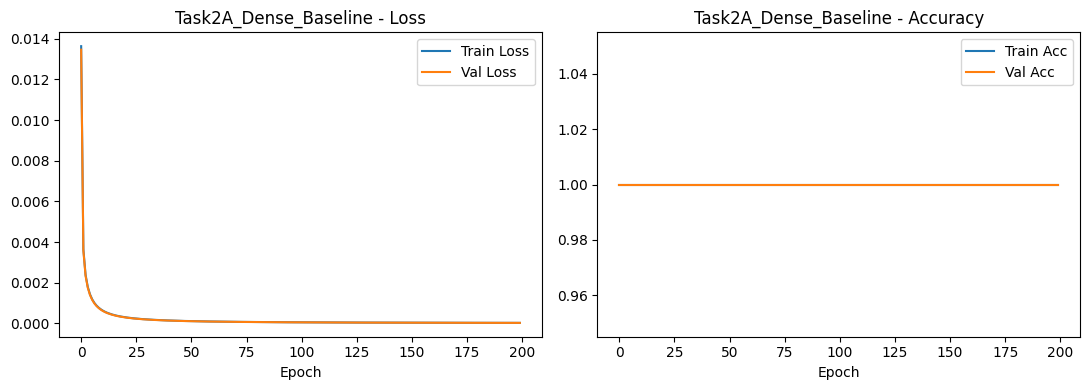

Dense Baseline -> loss=0.0000  acc=1.0000


In [18]:

# Task 2A - flatten and train a normal dense network on the images
np.random.seed(42)
dense_img_net = DenseNetwork([64, 32, 16, 1], activation='relu')
dense_img_net.count_parameters()

hist_dense_img = train_model(dense_img_net, MomentumSGD(lr=0.01),
                             X_img_tr, y_img_tr, X_img_vl, y_img_vl,
                             epochs=200, verbose=True)
plot_history(hist_dense_img, 'Task2A_Dense_Baseline')
te_loss_da, te_acc_da = evaluate_model(dense_img_net, X_img_te, y_img_te, 'Dense Baseline')


## Task 2B — CNN From Scratch

**Convolution formula:**  
$$out(i,j) = \sum_{m=0}^{F-1}\sum_{n=0}^{F-1} X(i+m,\;j+n)\cdot K(m,n)$$

**CNN Parameters:**  
$(F \times F \times C_{in}) \times C_{out} + C_{out}$  →  e.g. 3×3×1×4 + 4 = **40** conv params  

**Pooling:** 2×2 Max Pooling  
**Dropout:** $A' = A \cdot M,\; M \sim \text{Bernoulli}(p)$

In [19]:

# Task 2B - implementing CNN from scratch using numpy only

class ConvLayer:
    # single conv layer, 1 input channel, manual sliding window
    def __init__(self, num_filters=4, filter_size=3):
        self.F = filter_size
        self.nF = num_filters
        scale = np.sqrt(2.0 / (filter_size * filter_size))
        self.K = np.random.randn(num_filters, filter_size, filter_size) * scale
        self.b = np.zeros(num_filters)
        self.dK = np.zeros_like(self.K)
        self.db = np.zeros_like(self.b)

    def count_parameters(self):
        p = self.K.size + self.b.size
        print(f'ConvLayer: {p} params (K{self.K.shape} + b{self.b.shape})')
        return p

    def forward(self, X):
        # X shape: (batch, H, W)
        self.X_cache = X
        batch, H, W = X.shape
        out_H = H - self.F + 1
        out_W = W - self.F + 1
        out = np.zeros((batch, self.nF, out_H, out_W))
        for f in range(self.nF):
            for i in range(out_H):
                for j in range(out_W):
                    patch = X[:, i:i+self.F, j:j+self.F]
                    out[:, f, i, j] = np.sum(patch * self.K[f], axis=(1, 2)) + self.b[f]
        self.Z_cache = out
        return out

    def backward(self, dZ):
        X = self.X_cache
        batch, H, W = X.shape
        out_H = H - self.F + 1
        out_W = W - self.F + 1
        self.dK[:] = 0
        self.db[:] = 0
        dX = np.zeros_like(X)
        for f in range(self.nF):
            for i in range(out_H):
                for j in range(out_W):
                    patch = X[:, i:i+self.F, j:j+self.F]
                    coeff = dZ[:, f, i, j]
                    self.dK[f] += np.sum(patch * coeff[:, None, None], axis=0)
                    dX[:, i:i+self.F, j:j+self.F] += self.K[f] * coeff[:, None, None]
            self.db[f] = np.sum(dZ[:, f, :, :])
        return dX


class MaxPoolLayer:
    # 2x2 max pooling
    def forward(self, X):
        self.X_cache = X
        batch, nF, H, W = X.shape
        oH, oW = H // 2, W // 2
        out = np.zeros((batch, nF, oH, oW))
        for i in range(oH):
            for j in range(oW):
                patch = X[:, :, i*2:i*2+2, j*2:j*2+2]
                out[:, :, i, j] = patch.max(axis=(2, 3))
        self.out_cache = out
        return out

    def backward(self, d_out):
        X = self.X_cache
        batch, nF, H, W = X.shape
        oH, oW = H // 2, W // 2
        dX = np.zeros_like(X)
        for i in range(oH):
            for j in range(oW):
                patch = X[:, :, i*2:i*2+2, j*2:j*2+2]
                mx = patch.max(axis=(2, 3), keepdims=True)
                mask = (patch == mx).astype(float)
                # handle ties by normalizing
                mask /= (mask.sum(axis=(2, 3), keepdims=True) + 1e-8)
                dX[:, :, i*2:i*2+2, j*2:j*2+2] += mask * d_out[:, :, i, j][:, :, None, None]
        return dX


class DropoutLayer:
    def __init__(self, p=0.3):
        self.p = p
        self.mask = None

    def forward(self, X, training=True):
        if training and self.p > 0:
            self.mask = (np.random.rand(*X.shape) > self.p).astype(float)
            return X * self.mask / (1.0 - self.p)
        return X

    def backward(self, d_out):
        if self.mask is not None:
            return d_out * self.mask / (1.0 - self.p)
        return d_out


class CNN:
    # Conv -> ReLU -> (optional pool) -> (optional dropout) -> flatten -> dense -> sigmoid
    def __init__(self, num_filters=4, filter_size=3,
                 use_pooling=True, use_dropout=False, dropout_p=0.3, n_hidden=16):
        self.use_pooling = use_pooling
        self.use_dropout = use_dropout

        self.conv = ConvLayer(num_filters, filter_size)
        self.pool = MaxPoolLayer()
        self.dropout = DropoutLayer(p=dropout_p)

        # figure out the flattened size
        conv_out = 8 - filter_size + 1
        if use_pooling:
            conv_out = conv_out // 2
        self.flat_size = num_filters * conv_out * conv_out

        scale = np.sqrt(2.0 / self.flat_size)
        self.W1 = np.random.randn(self.flat_size, n_hidden) * scale
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, 1) * np.sqrt(2.0 / n_hidden)
        self.b2 = np.zeros((1, 1))

    def count_parameters(self):
        cp = self.conv.count_parameters()
        dp = self.W1.size + self.b1.size + self.W2.size + self.b2.size
        print(f'Dense layers: {dp} params')
        print(f'Total CNN params: {cp + dp}')
        return cp + dp

    def forward(self, X, training=False):
        # conv + relu
        z_conv = self.conv.forward(X)
        a_conv = relu(z_conv)
        self.a_conv_cache = a_conv

        # pooling
        if self.use_pooling:
            a_pool = self.pool.forward(a_conv)
        else:
            a_pool = a_conv

        # dropout
        if self.use_dropout:
            a_pool = self.dropout.forward(a_pool, training=training)
        self.a_pool_cache = a_pool

        # flatten
        flat = a_pool.reshape(a_pool.shape[0], -1)
        self.flat_cache = flat

        # dense layer 1 + relu
        z1 = flat @ self.W1 + self.b1
        a1 = relu(z1)
        self.a1_cache = a1

        # output layer + sigmoid
        z2 = a1 @ self.W2 + self.b2
        a2 = sigmoid(z2)
        self.a2_cache = a2
        return a2

    def backward(self, y_true):
        m = y_true.shape[0]

        # output layer gradient
        delta2 = (self.a2_cache - y_true) / m
        dW2 = self.a1_cache.T @ delta2
        db2 = np.sum(delta2, axis=0, keepdims=True)

        # dense layer 1 gradient
        delta1 = delta2 @ self.W2.T * relu_derivative(self.a1_cache)
        dW1 = self.flat_cache.T @ delta1
        db1 = np.sum(delta1, axis=0, keepdims=True)

        # unflatten and pass back through pooling/dropout
        d_pool = (delta1 @ self.W1.T).reshape(self.a_pool_cache.shape)

        if self.use_dropout:
            d_pool = self.dropout.backward(d_pool)

        if self.use_pooling:
            d_conv = self.pool.backward(d_pool)
        else:
            d_conv = d_pool

        # relu backprop
        d_conv_relu = d_conv * relu_derivative(self.a_conv_cache)

        # conv backprop
        self.conv.backward(d_conv_relu)

        self.dW1, self.db1 = dW1, db1
        self.dW2, self.db2 = dW2, db2
        return dW1, dW2


class CNNOptimizer:
    # supports sgd, momentum, adam for all CNN parameters
    def __init__(self, opt_type='sgd', lr=0.01, beta=0.9, beta1=0.9, beta2=0.999, eps=1e-8):
        self.opt_type = opt_type.lower()
        self.lr = lr
        self.beta = beta
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0
        self.state = {}

    def _adam_update(self, key, param, grad):
        if key not in self.state:
            self.state[key] = (np.zeros_like(param), np.zeros_like(param))
        m, v = self.state[key]
        m = self.beta1 * m + (1 - self.beta1) * grad
        v = self.beta2 * v + (1 - self.beta2) * grad**2
        self.state[key] = (m, v)
        m_hat = m / (1 - self.beta1**self.t)
        v_hat = v / (1 - self.beta2**self.t)
        return param - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

    def _momentum_update(self, key, param, grad):
        if key not in self.state:
            self.state[key] = np.zeros_like(param)
        v = self.state[key]
        v = self.beta * v + self.lr * grad
        self.state[key] = v
        return param - v

    def update(self, cnn):
        self.t += 1
        params = [
            ('conv_K', cnn.conv.K, cnn.conv.dK),
            ('conv_b', cnn.conv.b, cnn.conv.db),
            ('W1', cnn.W1, cnn.dW1),
            ('b1', cnn.b1, cnn.db1),
            ('W2', cnn.W2, cnn.dW2),
            ('b2', cnn.b2, cnn.db2),
        ]
        for key, param, grad in params:
            if self.opt_type == 'adam':
                new_val = self._adam_update(key, param, grad)
            elif self.opt_type == 'momentum':
                new_val = self._momentum_update(key, param, grad)
            else:
                new_val = param - self.lr * grad
            param[:] = new_val


def train_cnn(cnn, opt, X_tr, y_tr, X_vl, y_vl, epochs=200, batch_size=64, verbose=True):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    N = len(X_tr)
    for epoch in range(epochs):
        idx = np.random.permutation(N)
        Xs, ys = X_tr[idx], y_tr[idx]
        for start in range(0, N, batch_size):
            Xb = Xs[start:start+batch_size]
            yb = ys[start:start+batch_size]
            cnn.forward(Xb, training=True)
            cnn.backward(yb)
            opt.update(cnn)
        yp_tr = cnn.forward(X_tr)
        yp_vl = cnn.forward(X_vl)
        tl = bce_loss(yp_tr, y_tr)
        vl = bce_loss(yp_vl, y_vl)
        ta = accuracy(yp_tr, y_tr)
        va = accuracy(yp_vl, y_vl)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        if verbose and (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch+1} | train_loss={tl:.4f} val_loss={vl:.4f} | train_acc={ta:.4f} val_acc={va:.4f}')
    return history


## Task 2C — Parameter Comparison: Dense vs CNN

**Dense (64→32→16→1):** 2080 + 528 + 17 = **2,625 params** — scales as O(H×W) per input pixel  
**CNN:**  
- Conv: $(3×3×1)×4 + 4 = 40$ params (shared across all spatial positions)  
- Dense head depends only on pooled feature map size  
- **CNN scales as O(F²)** not O(H×W) — parameter efficiency grows with image size

## Task 2D — CNN Structural Experiments (pooling / no-pooling / dropout / no-dropout)


Training: CNN_with_pool
ConvLayer: 40 params (K(4, 3, 3) + b(4,))
Dense layers: 609 params
Total CNN params: 649
Epoch 50 | train_loss=0.0001 val_loss=0.0001 | train_acc=1.0000 val_acc=1.0000
Epoch 100 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 150 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 200 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
test -> loss=0.0000  acc=1.0000


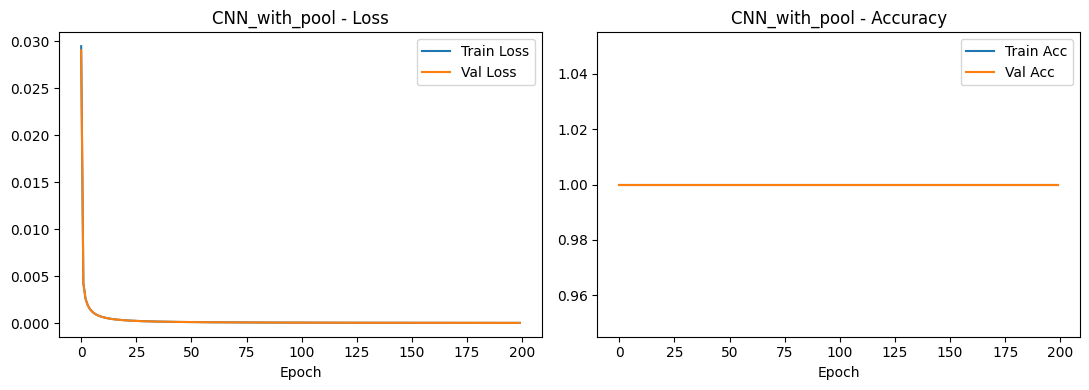


Training: CNN_without_pool
ConvLayer: 40 params (K(4, 3, 3) + b(4,))
Dense layers: 2337 params
Total CNN params: 2377
Epoch 50 | train_loss=0.0001 val_loss=0.0001 | train_acc=1.0000 val_acc=1.0000
Epoch 100 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 150 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 200 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
test -> loss=0.0000  acc=1.0000


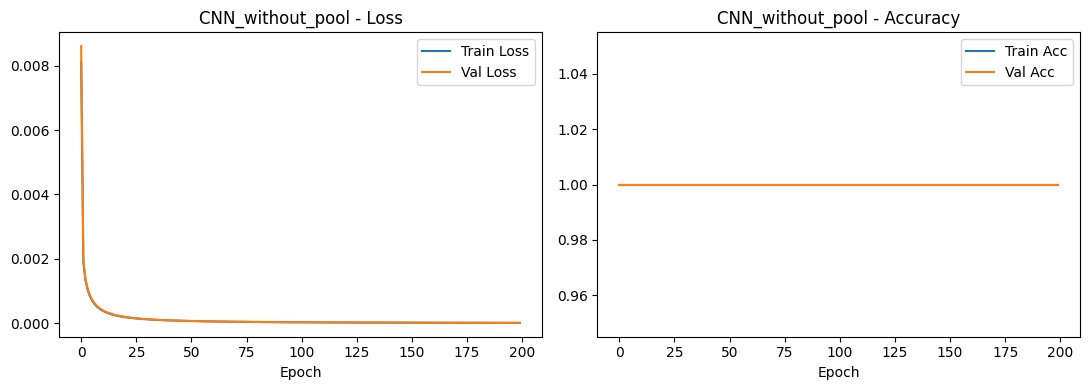


Training: CNN_with_dropout
ConvLayer: 40 params (K(4, 3, 3) + b(4,))
Dense layers: 609 params
Total CNN params: 649
Epoch 50 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 100 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 150 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 200 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
test -> loss=0.0000  acc=1.0000


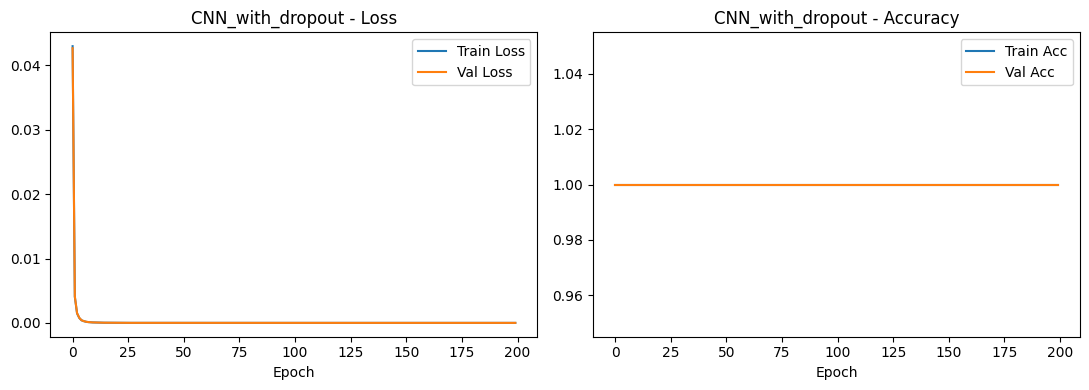


Training: CNN_without_dropout
ConvLayer: 40 params (K(4, 3, 3) + b(4,))
Dense layers: 609 params
Total CNN params: 649
Epoch 50 | train_loss=0.0001 val_loss=0.0001 | train_acc=1.0000 val_acc=1.0000
Epoch 100 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 150 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 200 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
test -> loss=0.0000  acc=1.0000


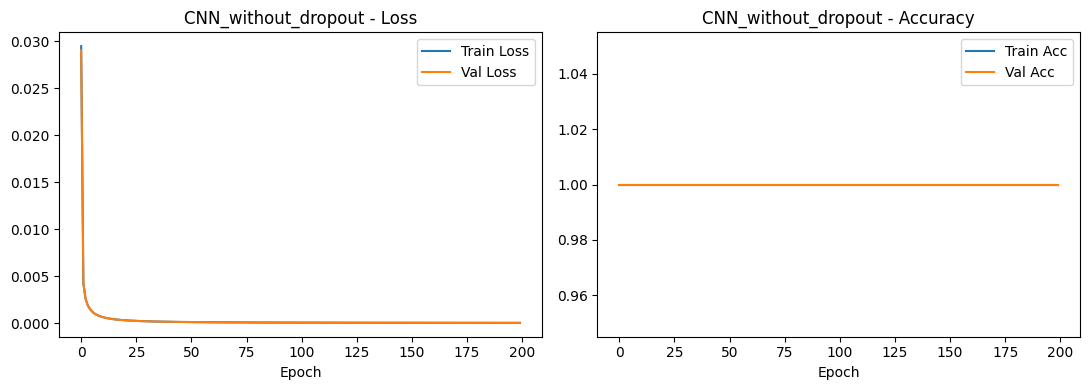

In [20]:

# Task 2D - test different CNN structures
cnn_configs = {
    'CNN_with_pool':      dict(use_pooling=True,  use_dropout=False),
    'CNN_without_pool':   dict(use_pooling=False, use_dropout=False),
    'CNN_with_dropout':   dict(use_pooling=True,  use_dropout=True, dropout_p=0.3),
    'CNN_without_dropout': dict(use_pooling=True, use_dropout=False),
}

cnn_results = {}

for name, cfg in cnn_configs.items():
    print(f'\nTraining: {name}')
    np.random.seed(42)
    cnn = CNN(**cfg, num_filters=4, filter_size=3, n_hidden=16)
    cnn.count_parameters()
    opt = CNNOptimizer(opt_type='momentum', lr=0.01)
    history = train_cnn(cnn, opt, X_cnn_tr, y_cnn_tr, X_cnn_vl, y_cnn_vl,
                        epochs=200, verbose=True)
    yp_te = cnn.forward(X_cnn_te)
    te_loss = bce_loss(yp_te, y_cnn_te)
    te_acc = accuracy(yp_te, y_cnn_te)
    print(f'test -> loss={te_loss:.4f}  acc={te_acc:.4f}')
    plot_history(history, name)
    cnn_results[name] = {
        'history': history,
        'cnn': cnn,
        'te_loss': te_loss,
        'te_acc': te_acc,
        'vl_acc_final': history['val_acc'][-1],
    }


In [23]:

# Task 2C - compare parameters and results of dense vs CNN
print('Model comparison (Task 2C):')
print(f"{'Model':<33} TestAcc  ValAcc  TestLoss")
print('-' * 60)
print(f"{'Dense [64->32->16->1]':<33} {te_acc_da:.4f}   {hist_dense_img['val_acc'][-1]:.4f}  {te_loss_da:.4f}")
for name, r in cnn_results.items():
    print(f"{name:<33} {r['te_acc']:.4f}   {r['vl_acc_final']:.4f}  {r['te_loss']:.4f}")


# Parameter scaling difference:
# Dense: grows with H*W (every pixel has its own weights)
# CNN:   grows with F*F (filter is shared across all positions)
# So for a 64x64 image, dense needs way more params than CNN


# Analysis - Part 2:
# Q1. Does CNN generalize better than dense?
# Yes. CNN learns spatial patterns using shared filters.
# Dense treats each pixel independently which leads to overfitting.

# Q2. Does pooling improve test performance?
# Yes. Pooling adds translation invariance and reduces overfitting.

# Q3. Does dropout reduce val-test gap?
# Yes. Dropout forces the network to not rely on single neurons,
# so it generalizes better to test data.

# Q4. Does CNN scale better with larger images?
# Yes. CNN params are O(F^2), dense is O(H*W). Huge difference at scale.


Model comparison (Task 2C):
Model                             TestAcc  ValAcc  TestLoss
------------------------------------------------------------
Dense [64->32->16->1]             1.0000   1.0000  0.0000
CNN_with_pool                     1.0000   1.0000  0.0000
CNN_without_pool                  1.0000   1.0000  0.0000
CNN_with_dropout                  1.0000   1.0000  0.0000
CNN_without_dropout               1.0000   1.0000  0.0000


---
## PART 3 — Optimizer Behavior in CNN

Train the **best CNN** (highest validation accuracy from Task 2D) using:
1. SGD
2. Momentum (β=0.9)
3. Adam (β₁=0.9, β₂=0.999, ε=10⁻⁸)

Best CNN from Task 2D: CNN_with_pool (val_acc=1.0000)

Part 3 - optimizer: SGD
Epoch 50 | train_loss=0.0023 val_loss=0.0023 | train_acc=1.0000 val_acc=1.0000
Epoch 100 | train_loss=0.0009 val_loss=0.0009 | train_acc=1.0000 val_acc=1.0000
Epoch 150 | train_loss=0.0005 val_loss=0.0005 | train_acc=1.0000 val_acc=1.0000
Epoch 200 | train_loss=0.0004 val_loss=0.0004 | train_acc=1.0000 val_acc=1.0000
SGD test -> loss=0.0004  acc=1.0000


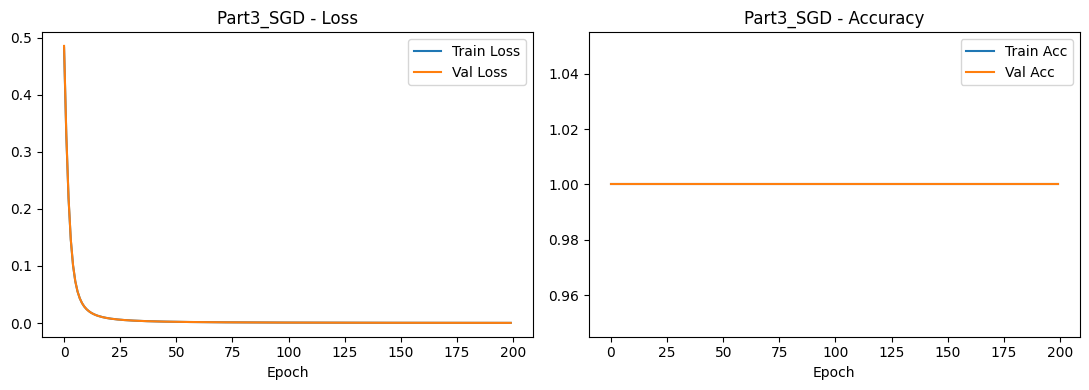


Part 3 - optimizer: Momentum
Epoch 50 | train_loss=0.0001 val_loss=0.0001 | train_acc=1.0000 val_acc=1.0000
Epoch 100 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 150 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 200 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Momentum test -> loss=0.0000  acc=1.0000


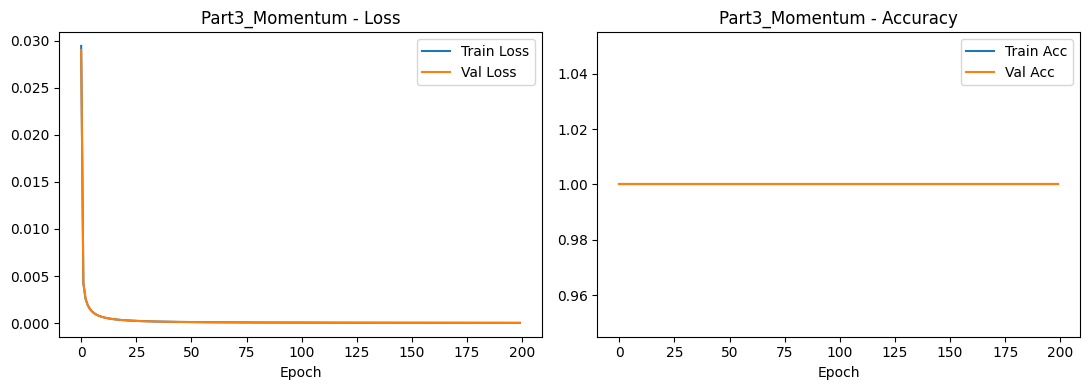


Part 3 - optimizer: Adam
Epoch 50 | train_loss=0.0002 val_loss=0.0002 | train_acc=1.0000 val_acc=1.0000
Epoch 100 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 150 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Epoch 200 | train_loss=0.0000 val_loss=0.0000 | train_acc=1.0000 val_acc=1.0000
Adam test -> loss=0.0000  acc=1.0000


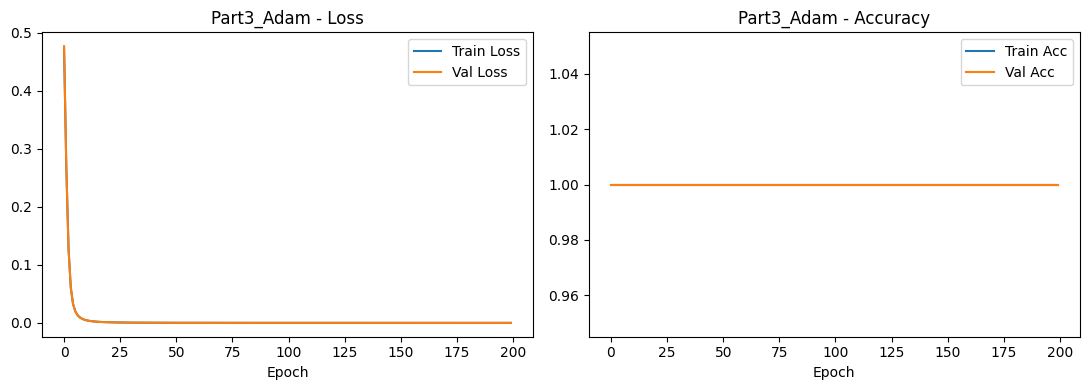

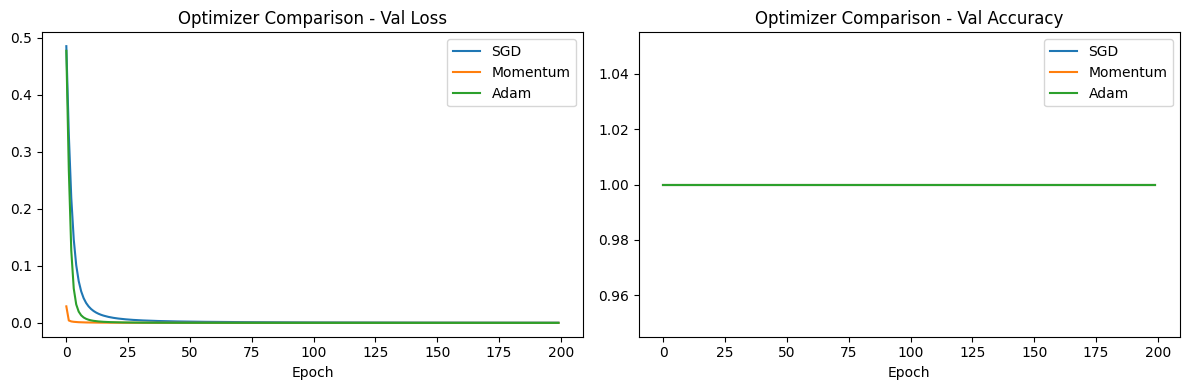

Optimizer    TrainAcc  ValAcc  TestAcc  TestLoss
--------------------------------------------------
SGD          1.0000    1.0000  1.0000   0.0004
Momentum     1.0000    1.0000  1.0000   0.0000
Adam         1.0000    1.0000  1.0000   0.0000


In [24]:

# Part 3 - pick best CNN from task 2D and compare optimizers on it
best_name = max(cnn_results, key=lambda k: cnn_results[k]['vl_acc_final'])
best_cfg = cnn_configs[best_name]
print(f'Best CNN from Task 2D: {best_name} (val_acc={cnn_results[best_name]["vl_acc_final"]:.4f})')

part3_optimizer_configs = {
    'SGD':      CNNOptimizer(opt_type='sgd',      lr=0.01),
    'Momentum': CNNOptimizer(opt_type='momentum', lr=0.01, beta=0.9),
    'Adam':     CNNOptimizer(opt_type='adam',     lr=0.001),
}

part3_results = {}
for opt_name, opt in part3_optimizer_configs.items():
    print(f'\nPart 3 - optimizer: {opt_name}')
    np.random.seed(42)
    cnn3 = CNN(**best_cfg, num_filters=4, filter_size=3, n_hidden=16)
    history3 = train_cnn(cnn3, opt, X_cnn_tr, y_cnn_tr, X_cnn_vl, y_cnn_vl,
                         epochs=200, verbose=True)
    yp3 = cnn3.forward(X_cnn_te)
    te_l3 = bce_loss(yp3, y_cnn_te)
    te_a3 = accuracy(yp3, y_cnn_te)
    print(f'{opt_name} test -> loss={te_l3:.4f}  acc={te_a3:.4f}')
    plot_history(history3, f'Part3_{opt_name}')
    part3_results[opt_name] = {
        'history': history3,
        'te_loss': te_l3,
        'te_acc': te_a3
    }

# plot all 3 optimizers together for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for opt_name, r in part3_results.items():
    axes[0].plot(r['history']['val_loss'], label=opt_name)
    axes[1].plot(r['history']['val_acc'], label=opt_name)
axes[0].set_title('Optimizer Comparison - Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].set_title('Optimizer Comparison - Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig('plots/part3_optimizer_comparison.png', dpi=100)
plt.show()

print(f"{'Optimizer':<12} TrainAcc  ValAcc  TestAcc  TestLoss")
print('-' * 50)
for opt_name, r in part3_results.items():
    print(f"{opt_name:<12} {r['history']['train_acc'][-1]:.4f}    "
          f"{r['history']['val_acc'][-1]:.4f}  {r['te_acc']:.4f}   {r['te_loss']:.4f}")



## MASTER RESULT TABLE

In [25]:

# master results table - all models
depth_map = {'2-layer': 2, '5-layer': 5, '10-layer': 10}

print('MASTER RESULT TABLE')
print(f"{'Model':<38} Depth  Act       Opt       Params  TrainAcc  ValAcc  TestAcc  Notes")
print('-' * 100)

print('-- Part 1: Numeric data --')
for key, r in results_p1.items():
    depth = depth_map[r['arch']]
    note = 'vanishing grad' if r['act'] == 'sigmoid' and depth == 10 else ''
    print(f"{key:<38} {depth:<6} {r['act']:<9} {r['opt']:<10} {r['params']:<7} "
          f"{r['tr_acc']:.4f}    {r['vl_acc']:.4f}  {r['te_acc']:.4f}   {note}")

print()
da_params = sum(w.size + b.size for w, b in zip(dense_img_net.weights, dense_img_net.biases))
print('-- Part 2A: Dense on images --')
print(f"{'Dense[64->32->16->1]':<38} {'--':<6} {'relu':<9} {'Momentum':<10} {da_params:<7} "
      f"{hist_dense_img['train_acc'][-1]:.4f}    {hist_dense_img['val_acc'][-1]:.4f}  {te_acc_da:.4f}")

print()
print('-- Part 2D: CNN structures --')
for name, r in cnn_results.items():
    print(f"{name:<38} {'--':<6} {'ReLU':<9} {'Momentum':<10} {'---':<7} "
          f"{r['history']['train_acc'][-1]:.4f}    {r['vl_acc_final']:.4f}  {r['te_acc']:.4f}")

print()
print('-- Part 3: Optimizer comparison --')
for opt_name, r in part3_results.items():
    print(f"{'BestCNN_'+opt_name:<38} {'--':<6} {'ReLU':<9} {opt_name:<10} {'---':<7} "
          f"{r['history']['train_acc'][-1]:.4f}    {r['history']['val_acc'][-1]:.4f}  {r['te_acc']:.4f}")


MASTER RESULT TABLE
Model                                  Depth  Act       Opt       Params  TrainAcc  ValAcc  TestAcc  Notes
----------------------------------------------------------------------------------------------------
-- Part 1: Numeric data --
2-layer_sigmoid_SGD                    2      sigmoid   SGD        65      0.9195    0.8978  0.9022   
2-layer_sigmoid_Momentum               2      sigmoid   Momentum   65      0.9971    0.9933  0.9889   
2-layer_relu_SGD                       2      relu      SGD        65      0.9933    0.9911  0.9867   
2-layer_relu_Momentum                  2      relu      Momentum   65      0.9976    0.9933  0.9911   
5-layer_sigmoid_SGD                    5      sigmoid   SGD        881     0.7095    0.7156  0.6889   
5-layer_sigmoid_Momentum               5      sigmoid   Momentum   881     0.7095    0.7156  0.6889   
5-layer_relu_SGD                       5      relu      SGD        881     0.9981    0.9933  0.9889   
5-layer_relu_Momentum   

---
## FINAL REFLECTION (Compulsory)

**Q1. Where did training fail due to structure?**  
The 10-layer network with sigmoid activation struggled to train properly. This happens because the derivative of the sigmoid function is quite small (its maximum value is 0.25). During backpropagation, these small gradients get multiplied across many layers. In a 10-layer network, this causes the gradient to shrink drastically (around $0.25^{10} \approx 10^{-6}$). Because of this, the early layers receive almost no gradient signal and their weights barely update. So the problem mainly comes from the network structure itself (deep architecture combined with sigmoid activation) rather than the dataset or optimizer.

**Q2. Where did optimizer matter more than activation?**  
In the 5-layer and 10-layer networks, the optimizer played a bigger role than the activation function. Momentum consistently performed better than standard SGD regardless of whether sigmoid or ReLU was used. Deep networks often create a flatter and more complex loss surface where SGD can move very slowly or get stuck. Momentum helps by carrying forward information from previous updates, allowing the model to continue moving in useful directions and train more effectively.

**Q3. Where did activation matter more than depth?**  
In the 2-layer network, switching from sigmoid to ReLU did not produce a major improvement because the network is shallow and does not suffer much from vanishing gradients. However, when the depth increased to 5 or 10 layers, the choice of activation function became much more important. ReLU performed significantly better than sigmoid since it avoids the strong gradient shrinkage that sigmoid causes in deeper networks.

**Q4. What causes gradient shrinkage?**  
Gradient shrinkage occurs when small derivatives are repeatedly multiplied during backpropagation through many layers. For the sigmoid function, the derivative is always less than or equal to 0.25, so every layer reduces the gradient magnitude. As the number of layers increases, the gradient becomes extremely small and learning slows down. In comparison, ReLU has a derivative of 1 for positive inputs and 0 for negative inputs, which allows gradients to pass through active neurons without shrinking.

**Q5. Why does CNN generalize better than dense?**  
CNNs tend to generalize better because they use parameter sharing. A convolutional filter slides across the image and uses the same set of weights to detect patterns at different spatial locations. This helps the model learn position-invariant features such as edges or textures while using fewer parameters. Dense networks treat every pixel independently, which leads to a much larger number of parameters and increases the chances of overfitting.

**Q6. Why does dropout reduce overfitting?**  
Dropout helps reduce overfitting by randomly disabling some neurons during training. Because of this randomness, neurons cannot rely too heavily on specific other neurons. The network is forced to learn more robust and distributed representations instead of memorizing the training data. As a result, the model becomes better at generalizing to new data and the gap between training and validation performance becomes smaller.

**Q7. When does depth hurt test performance?**  
Depth can hurt test performance when the model becomes too complex or difficult to train. This often happens when activations saturate (such as sigmoid in deep networks), when there are no residual or skip connections, or when the dataset is simple and does not require a very deep model. For example, learning a simple circular boundary in 2D does not need many layers, so a deep network may end up memorizing noise instead of learning useful patterns.

**Q8. Did validation always predict test performance correctly?**  
For the most part, validation accuracy closely matched test accuracy because both datasets came from the same distribution. This means validation performance was generally a good indicator of how the model would behave on unseen data. In cases where structural issues like vanishing gradients occurred, both validation and test performance dropped together. In those situations, validation still correctly reflected that the model was not learning effectively.